In [66]:
import pandas as pd # Import the pandas library for data manipulation and analysis
import matplotlib.pyplot as plt # Import the matplotlib.pyplot library for creating static, interactive, and animated visualizations
import seaborn as sns # Import the seaborn library for creating informative statistical graphics

In [67]:
# Load the dataset from the specified file path into a pandas DataFrame
df = pd.read_csv(r"C:\Users\caner\Desktop\EDA\Book Sales\Dataset\Books_Data_Clean.csv")

In [68]:
# Display the first 5 rows of the DataFrame to get a preview of the data
df.head()

,index,Publishing Year,Book Name,Author,language_code,Author_Rating,Book_average_rating,Book_ratings_count,genre,gross sales,publisher revenue,sale price,sales rank,Publisher,units sold
0,0,1975.0,Beowulf,"Unknown, Seamus Heaney",en-US,Novice,3.42,155903,genre fiction,34160.0,20496.0,4.88,1,HarperCollins Publishers,7000
1,1,1987.0,Batman: Year One,"Frank Miller, David Mazzucchelli, Richmond Lew...",eng,Intermediate,4.23,145267,genre fiction,12437.5,7462.5,1.99,2,HarperCollins Publishers,6250
2,2,2015.0,Go Set a Watchman,Harper Lee,eng,Novice,3.31,138669,genre fiction,47795.0,28677.0,8.69,3,"Amazon Digital Services, Inc.",5500
3,3,2008.0,When You Are Engulfed in Flames,David Sedaris,en-US,Intermediate,4.04,150898,fiction,41250.0,24750.0,7.50,3,Hachette Book Group,5500
4,4,2011.0,Daughter of Smoke & Bone,Laini Taylor,eng,Intermediate,4.04,198283,genre fiction,37952.5,22771.5,7.99,4,Penguin Group (USA) LLC,4750


In [69]:
# Generate descriptive statistics of the DataFrame, summarizing central tendency, dispersion, and shape of the dataset's distribution
df.describe()

,index,Publishing Year,Book_average_rating,Book_ratings_count,gross sales,publisher revenue,sale price,sales rank,units sold
count,1070.000000,1069.000000,1070.000000,1070.000000,1070.000000,1070.000000,1070.000000,1070.000000,1070.000000
mean,534.500000,1971.377923,4.007000,94909.913084,1856.622944,843.281030,4.869561,611.652336,9676.980374
std,309.026698,185.080257,0.247244,31513.242518,3936.924240,2257.596743,3.559919,369.849830,15370.571306
min,0.000000,-560.000000,2.970000,27308.000000,104.940000,0.000000,0.990000,1.000000,106.000000
25%,267.250000,1985.000000,3.850000,70398.000000,372.465000,0.000000,1.990000,287.500000,551.250000
50%,534.500000,2003.000000,4.015000,89309.000000,809.745000,273.078000,3.990000,595.500000,3924.000000
75%,801.750000,2010.000000,4.170000,113906.500000,1487.957500,721.180500,6.990000,932.500000,5312.250000
max,1069.000000,2016.000000,4.770000,206792.000000,47795.000000,28677.000000,33.860000,1273.000000,61560.000000


In [70]:
# Filter the DataFrame to include only books published after the year 1900
df = df[df["Publishing Year"] > 1900]

In [71]:
# Check for missing values in each column of the DataFrame and sum them up
df.isna().sum()

index                   0
Publishing Year         0
Book Name              21
Author                  0
language_code          49
Author_Rating           0
Book_average_rating     0
Book_ratings_count      0
genre                   0
gross sales             0
publisher revenue       0
sale price              0
sales rank              0
Publisher               0
units sold              0
dtype: int64

In [72]:
# Remove rows with missing values in the "Book Name" column, modifying the DataFrame in place
df.dropna(subset = "Book Name", inplace = True)

In [73]:
# Check for missing values again after dropping rows with missing "Book Name"
df.isna().sum()

index                   0
Publishing Year         0
Book Name               0
Author                  0
language_code          47
Author_Rating           0
Book_average_rating     0
Book_ratings_count      0
genre                   0
gross sales             0
publisher revenue       0
sale price              0
sales rank              0
Publisher               0
units sold              0
dtype: int64

In [74]:
# Check for duplicate rows in the DataFrame and sum them up
df.duplicated().sum()

np.int64(0)

In [75]:
# Get the number of unique values in each column of the DataFrame
df.nunique()

index                  988
Publishing Year        101
Book Name              987
Author                 669
language_code            8
Author_Rating            4
Book_average_rating    133
Book_ratings_count     983
genre                    4
gross sales            774
publisher revenue      570
sale price             143
sales rank             818
Publisher                9
units sold             470
dtype: int64

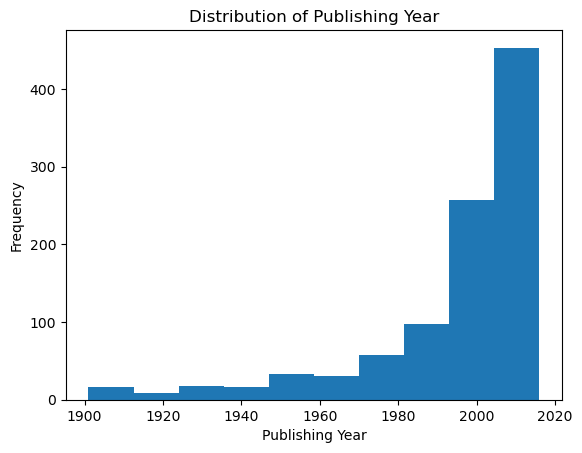

In [76]:
# Create a histogram of the "Publishing Year" column to visualize its distribution
plt.hist(df["Publishing Year"])
plt.xlabel("Publishing Year")
plt.ylabel("Frequency")
plt.title("Distribution of Publishing Year") # Set the title of the plot
plt.show()

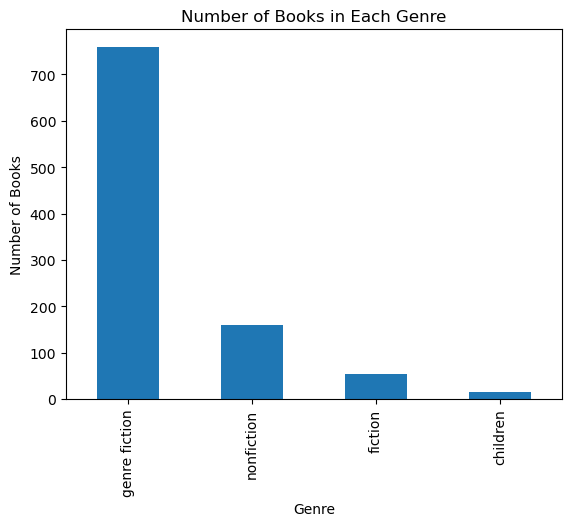

In [77]:
# Create a bar plot showing the count of books in each genre
df["genre"].value_counts().plot(kind="bar")
plt.xlabel("Genre")
plt.ylabel("Number of Books")
plt.title("Number of Books in Each Genre")
plt.show()

In [78]:
# Group the DataFrame by "Author" and calculate the mean of "Book_average_rating" for each author, then display the first 5 rows
df.groupby("Author")["Book_average_rating"].mean().head()

Author
A.A. Milne, Ernest H. Shepard     4.36
A.S.A. Harrison                   3.30
Abbi Glines                       4.21
Adam Johnson                      4.06
Adam Mansbach, Ricardo CortÃ©s    4.26
Name: Book_average_rating, dtype: float64

In [79]:
# Group the DataFrame by "Author" and calculate the mean of "Book_average_rating" for each author, then display the last 5 rows
df.groupby("Author")["Book_average_rating"].mean().tail()

Author
William Styron                                     4.18
Yana Toboso, Tomo Kimura                           4.37
Zadie Smith                                        3.75
Ø£Ø­Ù„Ø§Ù… Ù…Ø³ØªØºØ§Ù†Ù…ÙŠ, Ahlam Mosteghanemi    3.72
Ø£Ø­Ù…Ø¯ Ù…Ø±Ø§Ø¯                                  3.80
Name: Book_average_rating, dtype: float64

In [80]:
# Group the DataFrame by "Author", calculate the mean of "Book_average_rating", and reset the index to turn the grouped output into a DataFrame
df.groupby("Author")["Book_average_rating"].mean().reset_index()

,Author,Book_average_rating
0,"A.A. Milne, Ernest H. Shepard",4.36
1,A.S.A. Harrison,3.30
2,Abbi Glines,4.21
3,Adam Johnson,4.06
4,"Adam Mansbach, Ricardo CortÃ©s",4.26
...,...,...
664,William Styron,4.18
665,"Yana Toboso, Tomo Kimura",4.37
666,Zadie Smith,3.75
667,"Ø£Ø­Ù„Ø§Ù… Ù…Ø³ØªØºØ§Ù†Ù…ÙŠ, Ahlam Mosteghanemi",3.72


In [81]:
# Group the DataFrame by "Author", calculate the mean of "Book_average_rating", and sort the results in descending order
df.groupby("Author")["Book_average_rating"].mean().sort_values(ascending = False )

Author
Bill Watterson                  4.650000
Bill Watterson, G.B. Trudeau    4.610000
J.R.R. Tolkien                  4.590000
George R.R. Martin              4.560000
Sarah J. Maas                   4.526000
                                  ...   
Chetan Bhagat                   3.273333
Audrey Niffenegger              3.230000
Herman Koch, Sam Garrett        3.220000
P.D. James                      3.210000
Sue Monk Kidd                   3.100000
Name: Book_average_rating, Length: 669, dtype: float64

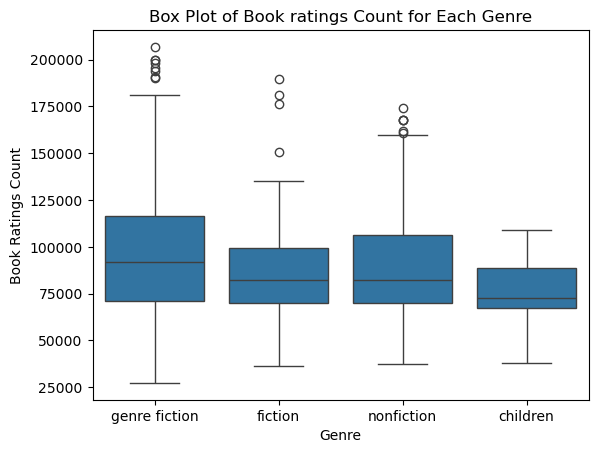

In [82]:
# Create a box plot to visualize the distribution of "Book_ratings_count" for each "genre"
sns.boxplot(x ="genre", y = "Book_ratings_count",data = df)
plt.xlabel("Genre")
plt.ylabel("Book Ratings Count")
plt.title("Box Plot of Book ratings Count for Each Genre")
plt.show()

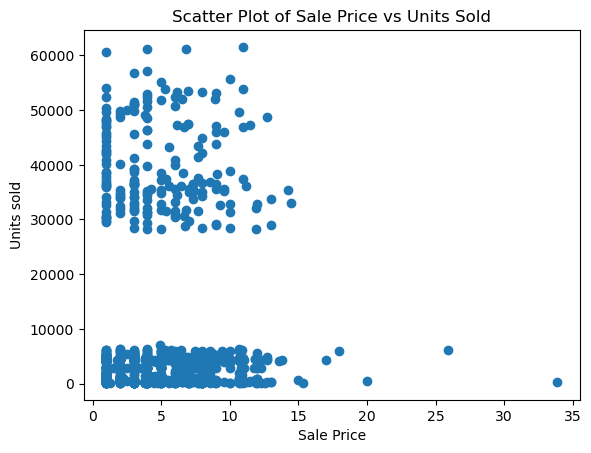

In [83]:
# Create a scatter plot to visualize the relationship between "sale price" and "units sold"
plt.scatter(df["sale price"],df["units sold"])
plt.xlabel("Sale Price")
plt.ylabel("Units sold")
plt.title("Scatter Plot of Sale Price vs Units Sold")
plt.show()

In [84]:
# Get the counts of each unique value in the "language_code" column
language_counts = df["language_code"].value_counts()

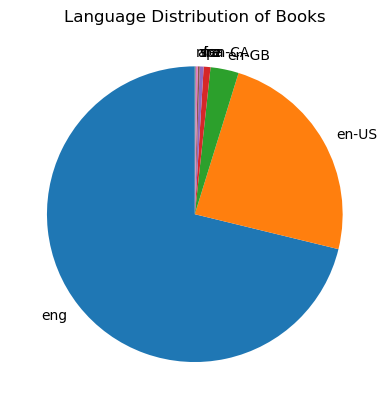

In [85]:
# Create a pie chart to visualize the distribution of language codes
plt.pie(language_counts , labels = language_counts.index , startangle = 90) # Create the pie chart with labels and starting angle
plt.title("Language Distribution of Books")
plt.show()

In [86]:
# Group the DataFrame by "Publisher", sum the "publisher revenue" for each publisher, and sort in descending order
df.groupby("Publisher ")["publisher revenue"].sum().sort_values(ascending = False )

Publisher 
Penguin Group (USA) LLC                 191581.104
Random House LLC                        174956.244
Amazon Digital Services,  Inc.          141767.772
HarperCollins Publishers                121769.814
Hachette Book Group                     107410.968
Simon and Schuster Digital Sales Inc     46858.206
Macmillan                                31249.830
HarperCollins Publishing                  2830.806
HarperCollins Christian Publishing        2135.670
Name: publisher revenue, dtype: float64

In [87]:
# Group by "Author_Rating", calculate the mean of "Book_ratings_count", sort in descending order, and find the maximum value
df.groupby("Author_Rating")["Book_ratings_count"].mean().sort_values(ascending=False).max()

101400.27256944444

In [88]:
# Group by "language_code", get the size of each group (number of books in each language), and sort in descending order
df.groupby("language_code").size().sort_values(ascending=False)

language_code
eng      670
en-US    226
en-GB     29
en-CA      7
fre        4
ara        2
spa        2
nl         1
dtype: int64

In [89]:
# Group by "Author_Rating" and calculate the median of "Book_ratings_count" for each author rating
df.groupby("Author_Rating")["Book_ratings_count"].median()

Author_Rating
Excellent       81609.5
Famous          90527.0
Intermediate    98254.5
Novice          77446.5
Name: Book_ratings_count, dtype: float64

In [90]:
# Group by "Author_Rating" and calculate the standard deviation of "Book_ratings_count" for each author rating
df.groupby("Author_Rating")["Book_ratings_count"].std()

Author_Rating
Excellent       21023.456069
Famous          35036.475144
Intermediate    34210.096082
Novice          30859.612389
Name: Book_ratings_count, dtype: float64

Text(0.5, 1.0, 'Scatter plot of Book Average Rating vs Book Ratings')

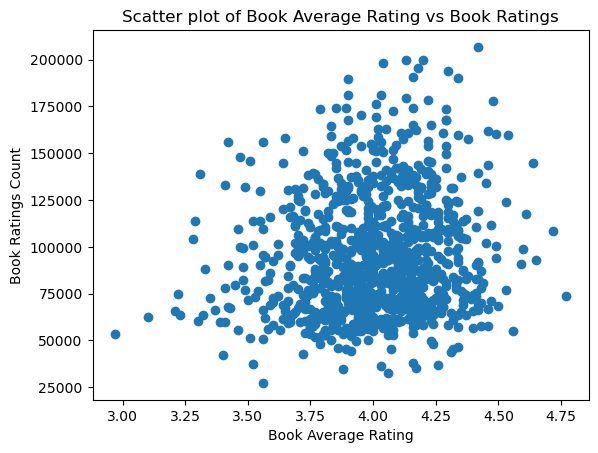

In [91]:
# Create a scatter plot to visualize the relationship between "Book_average_rating" and "Book_ratings_count"
plt.scatter(df["Book_average_rating"], df["Book_ratings_count"])
plt.xlabel("Book Average Rating")
plt.ylabel("Book Ratings Count")
plt.title("Scatter plot of Book Average Rating vs Book Ratings")

In [92]:
# Group the DataFrame by "Author" and calculate the total "gross sales" for each author
total_gross_sales_by_author = df.groupby("Author")["gross sales"].sum()

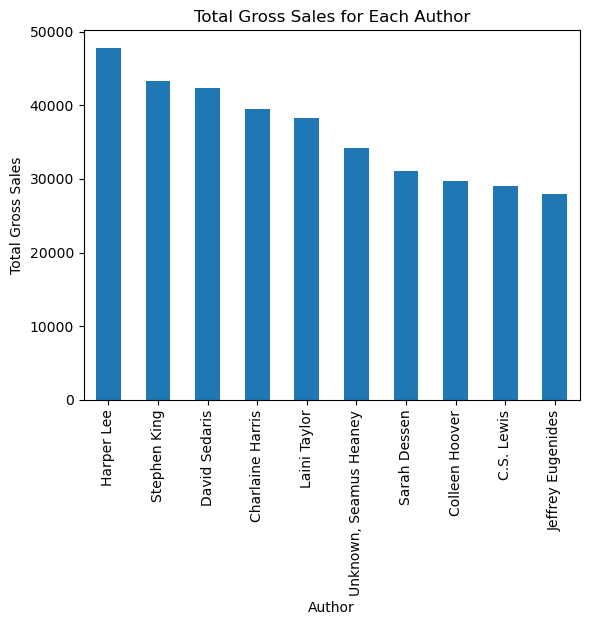

In [93]:
# Plot the top 10 authors by total gross sales as a bar chart
total_gross_sales_by_author.sort_values(ascending = False).head(10).plot(kind="bar")
plt.xlabel("Author")
plt.ylabel("Total Gross Sales")
plt.title("Total Gross Sales for Each Author")
plt.show()

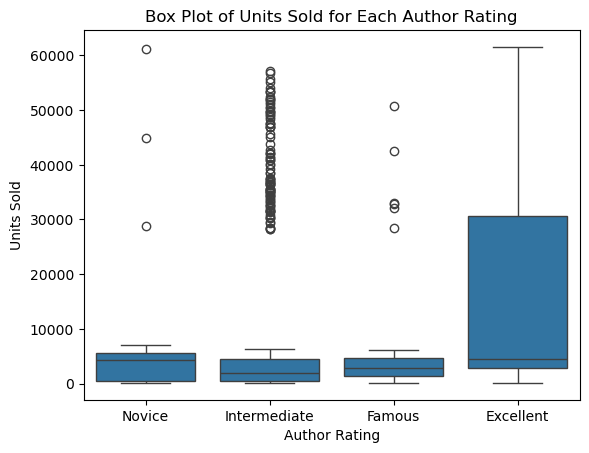

In [94]:
# Create a box plot to visualize the distribution of "units sold" for each "Author_Rating"
sns.boxplot(x="Author_Rating", y = "units sold", data = df)
plt.xlabel("Author Rating")
plt.ylabel("Units Sold")
plt.title("Box Plot of Units Sold for Each Author Rating")
plt.show()

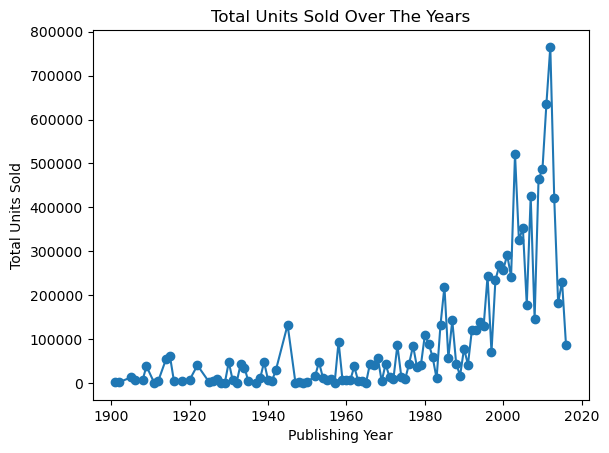

In [95]:
# Group by "Publishing Year", sum the "units sold" for each year, and plot the result as a line chart with markers
df.groupby("Publishing Year")["units sold"].sum().plot(kind="line", marker='o')
plt.xlabel("Publishing Year")
plt.ylabel("Total Units Sold")
plt.title("Total Units Sold Over The Years")
plt.show()